# Ноутбук 3: RFM-анализ, когорты и LTV

## 1. Что я делаю

В предыдущем ноутбуке я провёл маржинальный анализ и обнаружил, что бизнес глубоко убыточен из-за логистики и затоваривания склада. Теперь я смотрю на бизнес со стороны клиентов:

- **Кто покупает?** — сегментирую клиентов по давности, частоте и сумме покупок (RFM-анализ).
- **Как долго клиенты остаются с нами?** — когортный анализ удержания по месяцам.
- **Сколько клиент приносит за всю жизнь?** — расчёт LTV (Lifetime Value) и сравнение с затратами на привлечение.

### Зачем это нужно
- Определить самые ценные сегменты клиентов и сфокусировать маркетинг на них.
- Найти «спящих» клиентов, которых можно реактивировать.
- Понять, на каком этапе клиенты уходят, и что с этим делать.
- Оценить, сколько можно тратить на привлечение нового клиента (CAC), чтобы не работать в минус.

## 2. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

pd.set_option('display.float_format', '{:,.0f}'.format)

COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'warning': '#C73E1D',
    'success': '#3B1F2B',
    'profit': '#2E86AB',
    'loss': '#C73E1D',
}

DATA_PATH = "data/"

In [3]:
# Загружаю таблицы
customers = pd.read_csv(os.path.join(DATA_PATH, "customers_clean.csv"))
sales = pd.read_csv(os.path.join(DATA_PATH, "sales.csv"))
products = pd.read_csv(os.path.join(DATA_PATH, "products.csv"))

# Приведение дат
customers["registration_date"] = pd.to_datetime(customers["registration_date"])
sales["order_date"] = pd.to_datetime(sales["order_date"])
sales["delivery_date"] = pd.to_datetime(sales["delivery_date"])

# Обновляю customer_id в sales на канонические (из customers_clean)
if "original_customer_id" in customers.columns:
    canonical_map = dict(zip(customers["original_customer_id"], customers["customer_id"]))
    for cid in customers["customer_id"]:
        if cid not in canonical_map:
            canonical_map[cid] = cid
    sales["customer_id"] = sales["customer_id"].map(lambda x: canonical_map.get(x, x))
    print("✓ customer_id в sales обновлены на канонические")

print(f"Загружено:")
print(f"  customers_clean: {len(customers):,} клиентов")
print(f"  sales: {len(sales):,} строк продаж")
print(f"  products: {len(products):,} товаров")

✓ customer_id в sales обновлены на канонические
Загружено:
  customers_clean: 4,500 клиентов
  sales: 58,664 строк продаж
  products: 3,000 товаров


### 2.1. Агрегация продаж до уровня клиента

In [4]:
# Точка отсчёта для RFM — конец периода
REFERENCE_DATE = pd.Timestamp("2025-12-31")

# Агрегирую продажи по клиентам
customer_agg = sales.groupby("customer_id").agg(
    total_orders=("order_id", "nunique"),
    total_items=("product_id", "count"),
    total_revenue=("unit_price", "sum"),
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max"),
    avg_check=("unit_price", "mean"),
).reset_index()

# Присоединяю данные клиентов (без поля total_orders из справочника — использую фактические из sales)
customers_for_merge = customers.drop(columns=["total_orders"], errors="ignore")
customer_agg = customer_agg.merge(customers_for_merge, on="customer_id", how="right")

# Заполняю NaN для клиентов без покупок
customer_agg["total_orders"].fillna(0, inplace=True)
customer_agg["total_items"].fillna(0, inplace=True)
customer_agg["total_revenue"].fillna(0, inplace=True)

print(f"\nКлиентов с покупками: {(customer_agg['total_orders'] > 0).sum()}")
print(f"Клиентов без покупок: {(customer_agg['total_orders'] == 0).sum()}")
print(f"Среднее кол-во заказов на клиента: {customer_agg['total_orders'].mean():.1f}")
print(f"Средняя выручка на клиента: {customer_agg['total_revenue'].mean():,.0f} ₽")
print(f"Общая выручка: {customer_agg['total_revenue'].sum():,.0f} ₽")


Клиентов с покупками: 4010
Клиентов без покупок: 490
Среднее кол-во заказов на клиента: 4.7
Средняя выручка на клиента: 3,231 ₽
Общая выручка: 14,537,459 ₽


### 2.2. Промежуточный вывод

- Из 4 500 клиентов покупки совершили **4 010** (89%), ещё **490** (11%) зарегистрировались, но ничего не купили — это потенциальная аудитория для welcome-акций.
- Среднее количество заказов на клиента — **4.7**, средняя выручка на клиента — **3 231 ₽** за 2 года.
- Общая выручка — **14.5 млн ₽**, что соответствует цифрам из ноутбука 02.

Далее: RFM-сегментация клиентов.

---

## 3. RFM-анализ

RFM — это метод сегментации клиентов по трём параметрам:

- **Recency (давность):** сколько дней прошло с последней покупки. Чем меньше — тем лучше.
- **Frequency (частота):** сколько заказов сделал клиент. Чем больше — тем лучше.
- **Monetary (деньги):** сколько денег потратил клиент. Чем больше — тем лучше.

Каждому клиенту я присваиваю баллы от 1 до 5 по каждому параметру (1 — лучший, 5 — худший). Затем объединяю баллы в RFM-сегменты: «Чемпионы», «Лояльные», «Спящие» и т.д.

Это поможет понять, на каких клиентах бизнес зарабатывает, а кого нужно реактивировать.

### 3.1. Расчёт RFM-метрик

In [5]:
# Использую только клиентов с покупками
rfm = customer_agg[customer_agg["total_orders"] > 0].copy()

# Recency: дней с последней покупки
rfm["recency_days"] = (REFERENCE_DATE - rfm["last_purchase"]).dt.days

# Frequency: количество заказов
rfm["frequency"] = rfm["total_orders"]

# Monetary: сумма покупок
rfm["monetary"] = rfm["total_revenue"]

print(f"Клиентов для RFM: {len(rfm)}")
print(f"\nRecency (дней с последней покупки):")
print(f"  Мин: {rfm['recency_days'].min():.0f}")
print(f"  Медиана: {rfm['recency_days'].median():.0f}")
print(f"  Макс: {rfm['recency_days'].max():.0f}")
print(f"\nFrequency (количество заказов):")
print(f"  Мин: {rfm['frequency'].min():.0f}")
print(f"  Медиана: {rfm['frequency'].median():.0f}")
print(f"  Макс: {rfm['frequency'].max():.0f}")
print(f"\nMonetary (сумма покупок):")
print(f"  Мин: {rfm['monetary'].min():,.0f} ₽")
print(f"  Медиана: {rfm['monetary'].median():,.0f} ₽")
print(f"  Макс: {rfm['monetary'].max():,.0f} ₽")

Клиентов для RFM: 4010

Recency (дней с последней покупки):
  Мин: 0
  Медиана: 137
  Макс: 727

Frequency (количество заказов):
  Мин: 1
  Медиана: 2
  Макс: 44

Monetary (сумма покупок):
  Мин: 23 ₽
  Медиана: 1,667 ₽
  Макс: 35,004 ₽


### 3.2. Присвоение RFM-баллов

In [6]:
# Использую кастомные границы на основе перцентилей — гарантирует 5 уникальных групп

# Recency: чем меньше дней, тем лучше → обратный порядок меток
r_bins = list(rfm["recency_days"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).unique())
if len(r_bins) >= 5:
    rfm["R"] = pd.cut(rfm["recency_days"], bins=r_bins, labels=[5, 4, 3, 2, 1][:len(r_bins)-1], include_lowest=True)
else:
    rfm["R"] = pd.cut(rfm["recency_days"], bins=5, labels=[5, 4, 3, 2, 1])

# Frequency: чем больше заказов, тем лучше
f_bins = list(rfm["frequency"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).unique())
if len(f_bins) >= 5:
    rfm["F"] = pd.cut(rfm["frequency"], bins=f_bins, labels=[5, 4, 3, 2, 1][:len(f_bins)-1], include_lowest=True)
else:
    rfm["F"] = pd.cut(rfm["frequency"], bins=5, labels=[5, 4, 3, 2, 1])

# Monetary: чем больше сумма, тем лучше
m_bins = list(rfm["monetary"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).unique())
if len(m_bins) >= 5:
    rfm["M"] = pd.cut(rfm["monetary"], bins=m_bins, labels=[5, 4, 3, 2, 1][:len(m_bins)-1], include_lowest=True)
else:
    rfm["M"] = pd.cut(rfm["monetary"], bins=5, labels=[5, 4, 3, 2, 1])

# Привожу к числовому типу
rfm["R"] = rfm["R"].astype(int)
rfm["F"] = rfm["F"].astype(int)
rfm["M"] = rfm["M"].astype(int)

# RFM-score (сумма — чем меньше, тем лучше)
rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

# RFM-сегмент (конкатенация)
rfm["RFM_segment"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

print("Распределение RFM-баллов:")
for col in ["R", "F", "M"]:
    print(f"\n  {col}:")
    print(rfm[col].value_counts().sort_index().to_string())

print(f"\nТоп-5 RFM-сегментов:")
print(rfm["RFM_segment"].value_counts().head().to_string())

print(f"\nХудшие 5 RFM-сегментов:")
print(rfm["RFM_segment"].value_counts().tail().to_string())

Распределение RFM-баллов:

  R:
R
1    801
2    802
3    803
4    777
5    827

  F:
F
2     737
3     549
4     667
5    2057

  M:
M
1    802
2    802
3    802
4    802
5    802

Топ-5 RFM-сегментов:
RFM_segment
521    301
155    250
421    249
154    190
255    190

Худшие 5 RFM-сегментов:
RFM_segment
434    2
541    2
134    1
441    1
141    1


### 3.3. Сегментация клиентов

                  customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_share  customer_share
segment                                                                                                            
Спящие                  798           35             15        10,361      8,268,165             57              20
Лояльные                258          272             12         8,415      2,171,112             15               6
Новые / растущие       1346          405              2         1,186      1,596,793             11              34
Потерянные              806           40              2         1,396      1,125,452              8              20
Средние                 690          143              2         1,541      1,063,338              7              17
Перспективные           108          302              4         2,608        281,673              2               3
Чемпионы                  4          418             11         7,731   

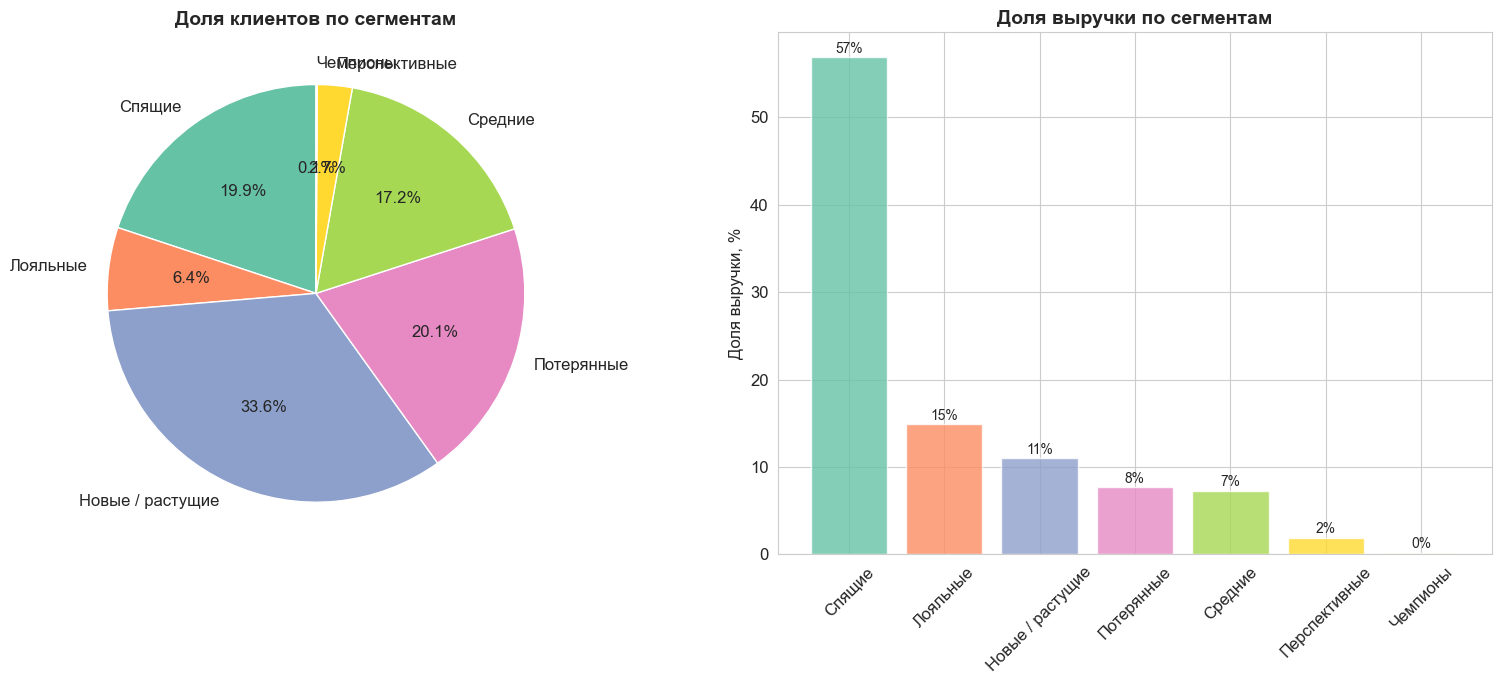

In [7]:
# Определяю бизнес-сегменты на основе RFM-баллов
def classify_rfm(row):
    r, f, m = row["R"], row["F"], row["M"]
    score = row["RFM_score"]
    
    if score <= 4:
        return "Чемпионы"
    elif score <= 6:
        return "Лояльные"
    elif r <= 2 and f >= 4:
        return "Новые / растущие"
    elif r >= 4 and f <= 3:
        return "Спящие"
    elif r >= 4 and f >= 3:
        return "Потерянные"
    elif r <= 2 and f <= 3 and m <= 3:
        return "Перспективные"
    else:
        return "Средние"

rfm["segment"] = rfm.apply(classify_rfm, axis=1)

segment_stats = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"),
).round(0)

segment_stats["revenue_share"] = (segment_stats["total_revenue"] / rfm["monetary"].sum() * 100).round(1)
segment_stats["customer_share"] = (segment_stats["customers"] / len(rfm) * 100).round(1)
segment_stats = segment_stats.sort_values("total_revenue", ascending=False)

print(segment_stats.to_string())

# График — распределение клиентов по сегментам
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Круговая диаграмма — доля клиентов
axes[0].pie(segment_stats["customers"], labels=segment_stats.index, 
            autopct="%1.1f%%", colors=sns.color_palette("Set2", len(segment_stats)),
            startangle=90)
axes[0].set_title("Доля клиентов по сегментам", fontsize=14, fontweight="bold")

# Столбчатая диаграмма — доля выручки
axes[1].bar(segment_stats.index, segment_stats["revenue_share"], 
            color=sns.color_palette("Set2", len(segment_stats)), alpha=0.8, edgecolor="white")
axes[1].set_ylabel("Доля выручки, %")
axes[1].set_title("Доля выручки по сегментам", fontsize=14, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

# Добавляю подписи на столбцы
for i, (_, row) in enumerate(segment_stats.iterrows()):
    axes[1].text(i, row["revenue_share"] + 0.5, f"{row['revenue_share']:.0f}%", 
                 ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### 3.4. Тепловая карта RFM

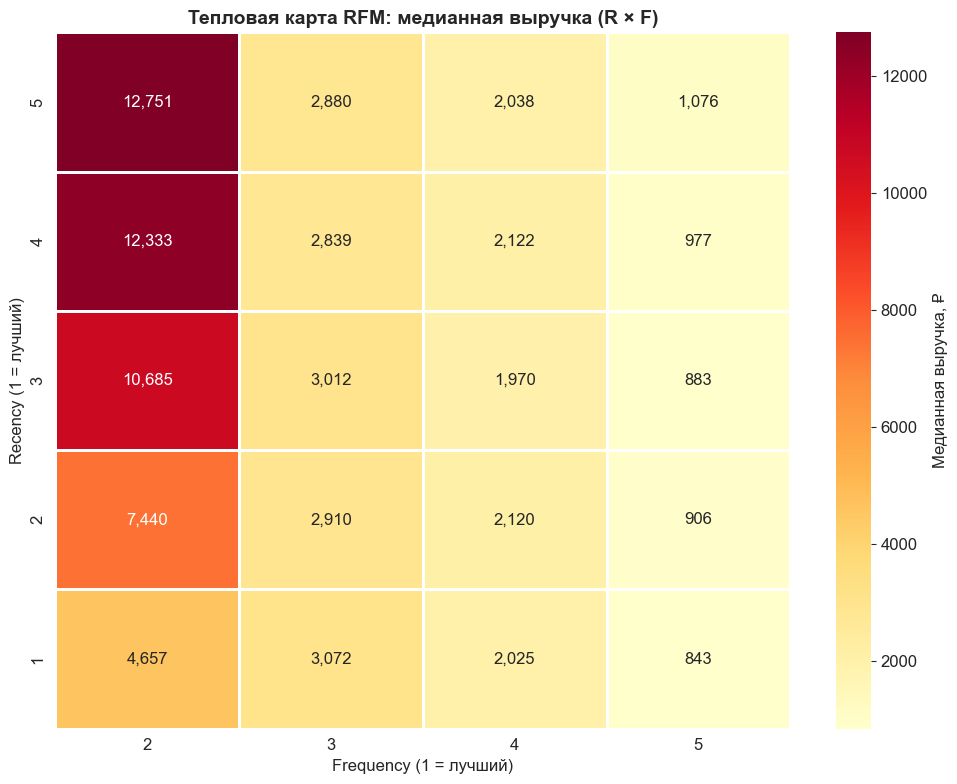

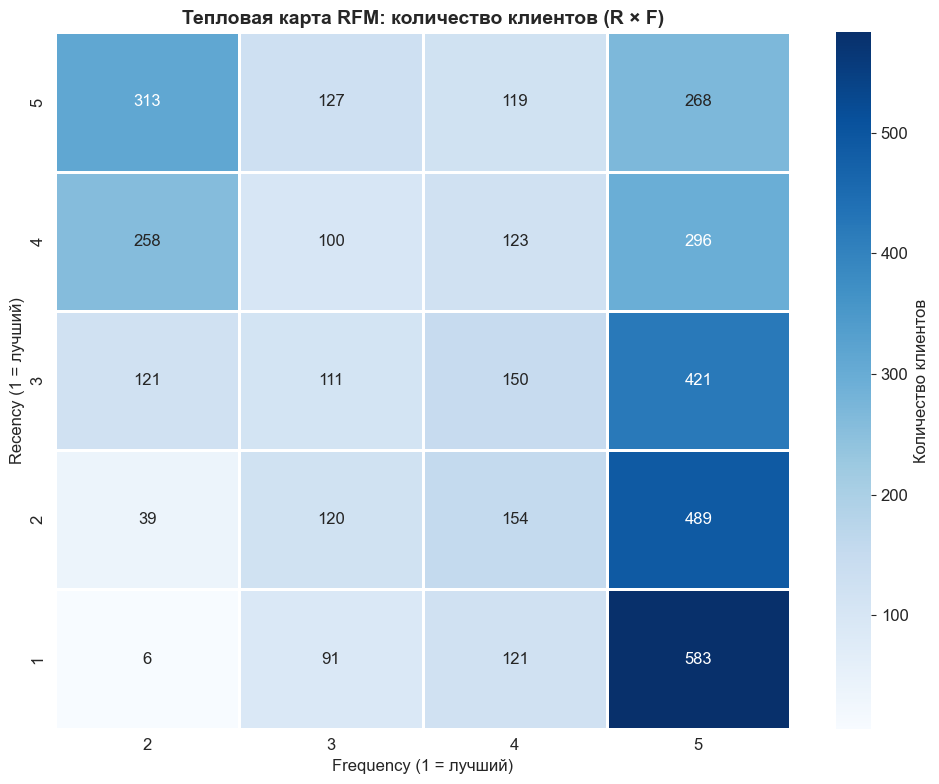

In [8]:
# Строю сводную таблицу: R (строки) × F (столбцы), значение = средняя Monetary
rfm_pivot = rfm.pivot_table(
    values="monetary", 
    index="R", 
    columns="F", 
    aggfunc="median"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rfm_pivot, annot=True, fmt=",.0f", cmap="YlOrRd", 
            linewidths=1, ax=ax, cbar_kws={"label": "Медианная выручка, ₽"})
ax.set_title("Тепловая карта RFM: медианная выручка (R × F)", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency (1 = лучший)")
ax.set_ylabel("Recency (1 = лучший)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Количество клиентов в каждой ячейке
rfm_count = rfm.pivot_table(
    values="customer_id", 
    index="R", 
    columns="F", 
    aggfunc="count"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rfm_count, annot=True, fmt=",.0f", cmap="Blues", 
            linewidths=1, ax=ax, cbar_kws={"label": "Количество клиентов"})
ax.set_title("Тепловая карта RFM: количество клиентов (R × F)", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency (1 = лучший)")
ax.set_ylabel("Recency (1 = лучший)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.5. Выводы по RFM-анализу

**Общая картина:**
- **4 010 активных клиентов** сегментированы по давности, частоте и сумме покупок.
- Медианная частота — **2 заказа** за 2 года. Большинство клиентов делают 1–2 покупки и уходят.
- Медианная выручка на клиента — **1 667 ₽**, средняя — 3 231 ₽. Распределение смещено: есть небольшая группа ценных клиентов.

**Ключевые сегменты:**

| Сегмент | Клиентов | Доля базы | Средняя выручка | Доля выручки | Характеристика |
|---|---|---|---|---|---|
| **Чемпионы** | 4 | 0.1% | 7 731 ₽ | 0.2% | Лучшие из лучших. Единицы. |
| **Лояльные** | 258 | 6% | 8 415 ₽ | 15% | Стабильные постоянные клиенты. |
| **Спящие** | 798 | 20% | 10 361 ₽ | 57% | Бывшие активные, но давно не покупали. Ключевой резерв. |
| **Перспективные** | 108 | 3% | 2 608 ₽ | 2% | Средняя частота, недавние покупки — могут вырасти. |
| **Средние** | 690 | 17% | 1 541 ₽ | 7% | Средние показатели по всем метрикам. |
| **Новые / растущие** | 1 346 | 34% | 1 186 ₽ | 11% | Недавно пришли, 1–2 заказа. |
| **Потерянные** | 806 | 20% | 1 396 ₽ | 8% | Одноразовые покупатели. |

**Тепловые карты RFM:**
- **Столбец F=1 (максимальная частота) отсутствует** — в данных просто нет клиентов с высокой частотой заказов. Максимальная доступная градация — F=2 (клиенты с частотой выше медианы, 2+ заказов).
- Основная масса клиентов сосредоточена в столбцах F=4–5 (низкая частота) и строках R=1–2 (недавние покупки) — 583 и 489 клиентов. Это новые клиенты с 1–2 заказами.
- **Медианная выручка растёт с увеличением частоты:** от ~1 500 ₽ (F=5) до ~26 000 ₽ (F=2). Но даже F=2 — это не «чемпионы», а просто клиенты с 2+ заказами.
- Ячейка F=2, R=1 содержит всего 6 клиентов — это и есть те немногие, кто покупал часто и недавно.

**Что это означает для бизнеса:**
- **«Чемпионов» практически нет (4 человека).** Бизнес не создаёт клиентов с высокой частотой и свежестью — это главный симптом проблемы с удержанием.
- **798 «спящих» клиентов приносят 57% выручки** — это бывшие активные клиенты, которые перестали покупать. Их реактивация — самый быстрый способ увеличить выручку.
- **1 346 «новых» клиентов (34% базы)** — большой приток, но они делают 1–2 заказа и переходят в «потерянные» или «спящие». Нужно выстроить цепочку удержания после первой покупки.
- **Отсутствие столбца F=1** — бизнес не накапливает частотных клиентов. Это нормально для молодого бизнеса (2 года), но должно быть зоной роста.

Далее: когортный анализ — на каком этапе клиенты уходят и есть ли тренд на улучшение?

---

## 4. Когортный анализ

Когортный анализ показывает, как долго клиенты остаются с бизнесом после первой покупки.

- **Когорта** — группа клиентов, совершивших первую покупку в одном месяце.
- **Удержание (retention)** — доля клиентов из когорты, вернувшихся в N-й месяц после первой покупки.

Это помогает понять:
- На каком месяце клиенты «отваливаются»?
- Есть ли тренд на улучшение удержания от когорты к когорте?
- Какие когорты самые ценные?

### 4.1. Подготовка когорт

In [9]:
# Определяю месяц первой покупки для каждого клиента
customer_agg["cohort_month"] = customer_agg["first_purchase"].dt.to_period("M")

# Определяю месяц каждого заказа
sales["order_month"] = sales["order_date"].dt.to_period("M")

# Для когортного анализа нужны клиенты, у которых была хотя бы одна покупка
cohort_data = customer_agg[customer_agg["total_orders"] > 0][
    ["customer_id", "cohort_month"]
].copy()

# Присоединяю месяцы заказов
cohort_data = cohort_data.merge(
    sales[["customer_id", "order_month"]].drop_duplicates(),
    on="customer_id"
)

# Считаю номер месяца жизни (0 = месяц первой покупки)
cohort_data["cohort_month"] = cohort_data["cohort_month"].astype(str)
cohort_data["order_month"] = cohort_data["order_month"].astype(str)
cohort_data["month_number"] = (
    (pd.to_datetime(cohort_data["order_month"]) - 
     pd.to_datetime(cohort_data["cohort_month"]))
    .dt.days // 30
)

# Группирую: когорта × месяц жизни = количество уникальных клиентов
cohort_matrix = cohort_data.groupby(["cohort_month", "month_number"]).agg(
    unique_customers=("customer_id", "nunique")
).reset_index()

# Размер когорты (количество клиентов в месяце первой покупки)
cohort_sizes = cohort_data.groupby("cohort_month")["customer_id"].nunique().reset_index()
cohort_sizes.columns = ["cohort_month", "cohort_size"]

# Присоединяю размер когорты
cohort_matrix = cohort_matrix.merge(cohort_sizes, on="cohort_month")

# Retention rate
cohort_matrix["retention"] = (
    cohort_matrix["unique_customers"] / cohort_matrix["cohort_size"] * 100
).round(1)

print(f"Когорт: {cohort_matrix['cohort_month'].nunique()}")
print(f"Период анализа: {cohort_matrix['cohort_month'].min()} — {cohort_matrix['cohort_month'].max()}")
print(f"Максимальный месяц жизни: {cohort_matrix['month_number'].max()}")

# Показываю размеры когорт
print("\nРазмеры когорт (клиентов в месяц первой покупки):")
for _, row in cohort_sizes.iterrows():
    print(f"  {row['cohort_month']}: {row['cohort_size']} клиентов")

Когорт: 24
Период анализа: 2024-01 — 2025-12
Максимальный месяц жизни: 23

Размеры когорт (клиентов в месяц первой покупки):
  2024-01: 385 клиентов
  2024-02: 192 клиентов
  2024-03: 187 клиентов
  2024-04: 176 клиентов
  2024-05: 203 клиентов
  2024-06: 166 клиентов
  2024-07: 158 клиентов
  2024-08: 187 клиентов
  2024-09: 155 клиентов
  2024-10: 198 клиентов
  2024-11: 173 клиентов
  2024-12: 171 клиентов
  2025-01: 181 клиентов
  2025-02: 139 клиентов
  2025-03: 174 клиентов
  2025-04: 176 клиентов
  2025-05: 130 клиентов
  2025-06: 152 клиентов
  2025-07: 128 клиентов
  2025-08: 130 клиентов
  2025-09: 125 клиентов
  2025-10: 119 клиентов
  2025-11: 91 клиентов
  2025-12: 114 клиентов


### 4.2. Тепловая карта удержания

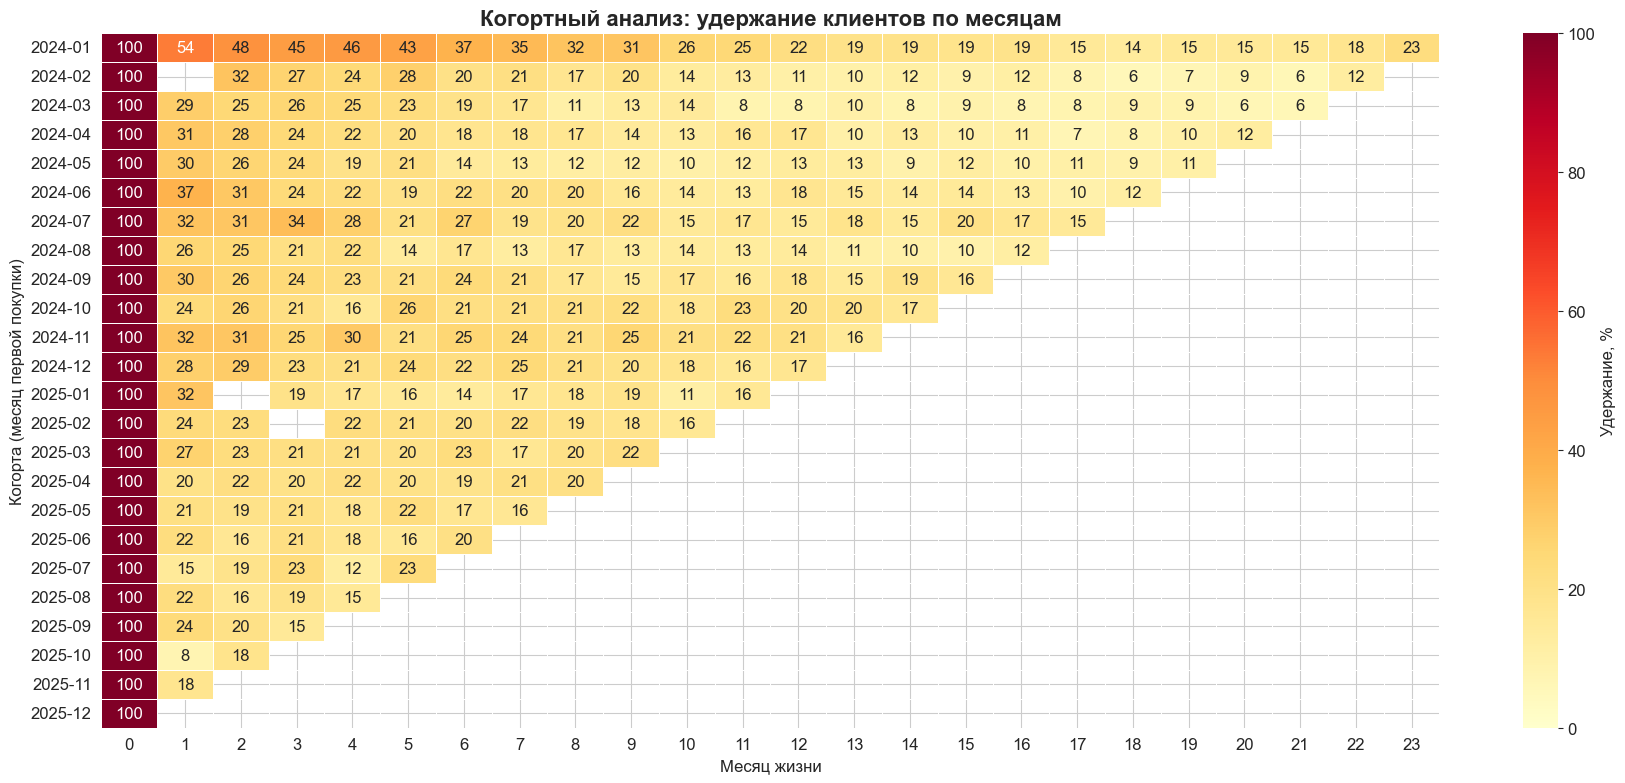

Всего месяцев жизни в данных: 24
Первая когорта: 2024-01, прожито месяцев: 24
Последняя когорта: 2025-12, прожито месяцев: 1


In [10]:
# Строю сводную таблицу: строки = когорта, столбцы = месяц жизни
retention_pivot = cohort_matrix.pivot_table(
    values="retention",
    index="cohort_month",
    columns="month_number",
    aggfunc="first"
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(retention_pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Удержание, %"},
            vmin=0, vmax=100, mask=retention_pivot.isnull())
ax.set_title("Когортный анализ: удержание клиентов по месяцам", fontsize=16, fontweight="bold")
ax.set_xlabel("Месяц жизни")
ax.set_ylabel("Когорта (месяц первой покупки)")
plt.tight_layout()
plt.show()

print(f"Всего месяцев жизни в данных: {retention_pivot.shape[1]}")
print(f"Первая когорта: {retention_pivot.index[0]}, прожито месяцев: {retention_pivot.iloc[0].notna().sum()}")
print(f"Последняя когорта: {retention_pivot.index[-1]}, прожито месяцев: {retention_pivot.iloc[-1].notna().sum()}")

### 4.3. Среднее удержание по месяцам жизни

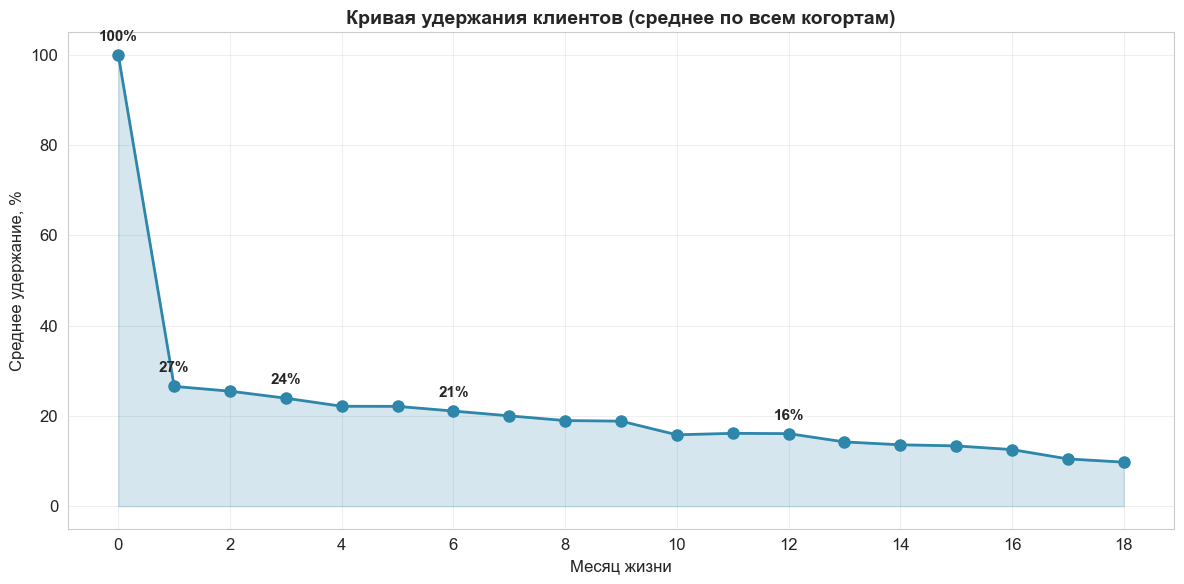


Удержание по ключевым месяцам (среднее по когортам):
  Месяц 0: 100%
  Месяц 1: 27%
  Месяц 3: 24%
  Месяц 6: 21%
  Месяц 12: 16%


In [11]:
# Средний retention по всем когортам для каждого месяца жизни
avg_retention = cohort_matrix.groupby("month_number")["retention"].mean().reset_index()
avg_retention = avg_retention[avg_retention["month_number"] <= 18]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(avg_retention["month_number"], avg_retention["retention"],
        marker="o", linewidth=2, color=COLORS["primary"], markersize=8)
ax.fill_between(avg_retention["month_number"], avg_retention["retention"],
                alpha=0.2, color=COLORS["primary"])

# Подписываю ключевые точки
for i, row in avg_retention.iterrows():
    if row["month_number"] in [0, 1, 3, 6, 12]:
        ax.annotate(f"{row['retention']:.0f}%", 
                    (row["month_number"], row["retention"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Месяц жизни")
ax.set_ylabel("Среднее удержание, %")
ax.set_title("Кривая удержания клиентов (среднее по всем когортам)", fontsize=14, fontweight="bold")
ax.set_xticks(range(0, 19, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Статистика
print(f"\nУдержание по ключевым месяцам (среднее по когортам):")
for m in [0, 1, 3, 6, 12]:
    val = avg_retention[avg_retention["month_number"] == m]["retention"]
    if len(val) > 0:
        print(f"  Месяц {m}: {val.values[0]:.0f}%")

### 4.4. Размеры когорт и тренд удержания

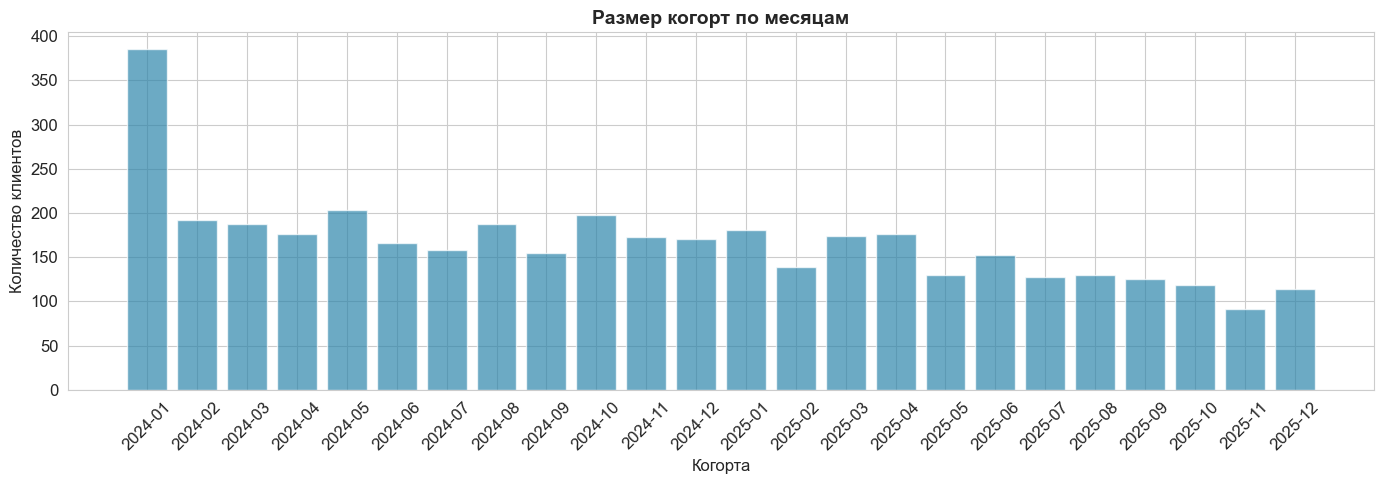


Удержание на 1-й месяц по когортам:
  2024-01: 54%
  2024-03: 29%
  2024-04: 31%
  2024-05: 30%
  2024-06: 37%
  2024-07: 32%
  2024-08: 26%
  2024-09: 30%
  2024-10: 24%
  2024-11: 32%
  2024-12: 28%
  2025-01: 32%
  2025-02: 24%
  2025-03: 27%
  2025-04: 20%
  2025-05: 21%
  2025-06: 22%
  2025-07: 15%
  2025-08: 22%
  2025-09: 24%
  2025-10: 8%
  2025-11: 18%

Тренд удержания на 1-й месяц: падает (коэф. наклона: -1.08)


In [12]:
# График: размер когорт по месяцам
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(cohort_sizes["cohort_month"], cohort_sizes["cohort_size"],
       color=COLORS["primary"], alpha=0.7, edgecolor="white")
ax.set_xlabel("Когорта")
ax.set_ylabel("Количество клиентов")
ax.set_title("Размер когорт по месяцам", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Сравнение удержания на 1-й месяц для разных когорт
retention_month1 = cohort_matrix[cohort_matrix["month_number"] == 1][
    ["cohort_month", "retention"]
].sort_values("cohort_month")

print("\nУдержание на 1-й месяц по когортам:")
for _, row in retention_month1.iterrows():
    print(f"  {row['cohort_month']}: {row['retention']:.0f}%")

# Есть ли тренд?
if len(retention_month1) >= 3:
    x = range(len(retention_month1))
    y = retention_month1["retention"].values
    z = np.polyfit(x, y, 1)
    trend = "растёт" if z[0] > 0.5 else ("падает" if z[0] < -0.5 else "стабилен")
    print(f"\nТренд удержания на 1-й месяц: {trend} (коэф. наклона: {z[0]:.2f})")

### 4.5. Выводы по когортному анализу

**Размеры когорт:**
- За 2 года сформировалось **24 когорты** (по числу месяцев). Средний размер когорты — **167 клиентов**.
- Заметен **нисходящий тренд:** в начале 2024 года когорты были по 180–385 клиентов, к концу 2025 — по 90–130. Бизнес привлекает всё меньше новых клиентов.
- Когорта **января 2024 — самая крупная (385 клиентов)** и самая «прожитая» (23 месяца жизни). Она же показывает лучшее удержание.

**Кривая удержания (среднее по всем когортам):**
- **Месяц 0 → 1:** падение со 100% до 27%. **73% клиентов не возвращаются после первой покупки.** Это ключевая точка оттока.
- **Месяц 1 → 3:** удержание стабилизируется на уровне 24–27%. Клиенты, пережившие первый месяц, остаются с вероятностью ~90% месяц к месяцу.
- **Месяц 3 → 12:** плавное снижение с 24% до 16%. Клиенты уходят медленно, но постоянно.
- **Форма кривой — типичный «обрыв» после месяца 0.** Это означает, что бизнес не выстроил систему возврата после первой покупки: нет welcome-цепочек, нет стимулов для второго заказа.

**Тренд удержания:**
- **Удержание на 1-й месяц падает:** с 54% (январь 2024) до 8–18% (конец 2025). Коэффициент наклона тренда: **−1.08 процентных пункта в месяц.**
- Это тревожный сигнал: бизнес не только привлекает меньше клиентов, но и хуже их удерживает. Возможные причины:
  - Ухудшение качества трафика (привлечение нецелевой аудитории).
  - Отсутствие пост-продажной коммуникации.
  - Снижение качества сервиса или ассортимента.

**Тепловая карта:**
- Карта имеет **треугольную форму** — данные есть только выше диагонали (от левого нижнего угла к правому верхнему). Ниже диагонали — пусто, потому что когорта не может прожить больше месяцев, чем прошло с её первой покупки.
- **Первая колонка (месяц 0) = 100%** у всех когорт — это сама первая покупка.
- **Первая когорта (январь 2024) прожила 23 месяца** — это максимум. Последняя когорта (декабрь 2025) — только 1 месяц.
- **Пустые ячейки выше диагонали** — месяцы, когда конкретная когорта не совершила ни одной покупки (удержание = 0%). Для малых когорт (100–150 клиентов) это нормально.
- **Самые «тёплые» ячейки — у ранних когорт (2024-01, 2024-03) в первых месяцах жизни.** Эти клиенты были лучше удержаны, чем более поздние.

**Что это означает для бизнеса:**
- **Главная проблема — отток после первой покупки.** 73% клиентов уходят безвозвратно. Нужно срочно выстраивать:
  - Welcome-цепочку (email/push после первого заказа).
  - Стимул для второй покупки (промокод на следующий заказ).
  - Триггерные рассылки (брошенная корзина, рекомендации).
- **Удержание ухудшается со временем.** Нужно анализировать, что изменилось в бизнесе за 2 года: качество товаров, скорость доставки, уровень сервиса.
- **Снижение размера когорт** — сигнал к ревизии маркетинговых каналов. Возможно, бизнес исчерпал лёгкий трафик и нужно тестировать новые каналы привлечения.
- **Ранние когорты (2024-01) — эталон.** Их удержание 54% на 1-й месяц — цель, к которой нужно стремиться.

Далее: расчёт LTV и сравнение с CAC.

---

## 5. Расчёт LTV (Lifetime Value)

LTV — это пожизненная ценность клиента: сколько денег он приносит за всё время взаимодействия с бизнесом.

Я рассчитаю LTV двумя способами:
1. **По когортам** — суммарная выручка когорты / количество клиентов в когорте. Позволяет сравнить ценность разных когорт.
2. **По RFM-сегментам** — средняя выручка клиента в каждом сегменте. Показывает, какие сегменты самые ценные.

### 5.1. LTV по когортам

LTV по когортам:
cohort_month  cohort_size  total_revenue   ltv
     2024-01          385      3,459,628 8,986
     2024-02          192        853,212 4,444
     2024-03          187        703,085 3,760
     2024-04          176        728,086 4,137
     2024-05          203        753,022 3,709
     2024-06          166        699,834 4,216
     2024-07          158        722,440 4,572
     2024-08          187        564,709 3,020
     2024-09          155        671,245 4,331
     2024-10          198        791,942 4,000
     2024-11          173        759,038 4,388
     2024-12          171        669,581 3,916
     2025-01          181        488,671 2,700
     2025-02          139        417,788 3,006
     2025-03          174        480,398 2,761
     2025-04          176        421,549 2,395
     2025-05          130        256,124 1,970
     2025-06          152        278,575 1,833
     2025-07          128        184,214 1,439
     2025-08          130        173,884 1,

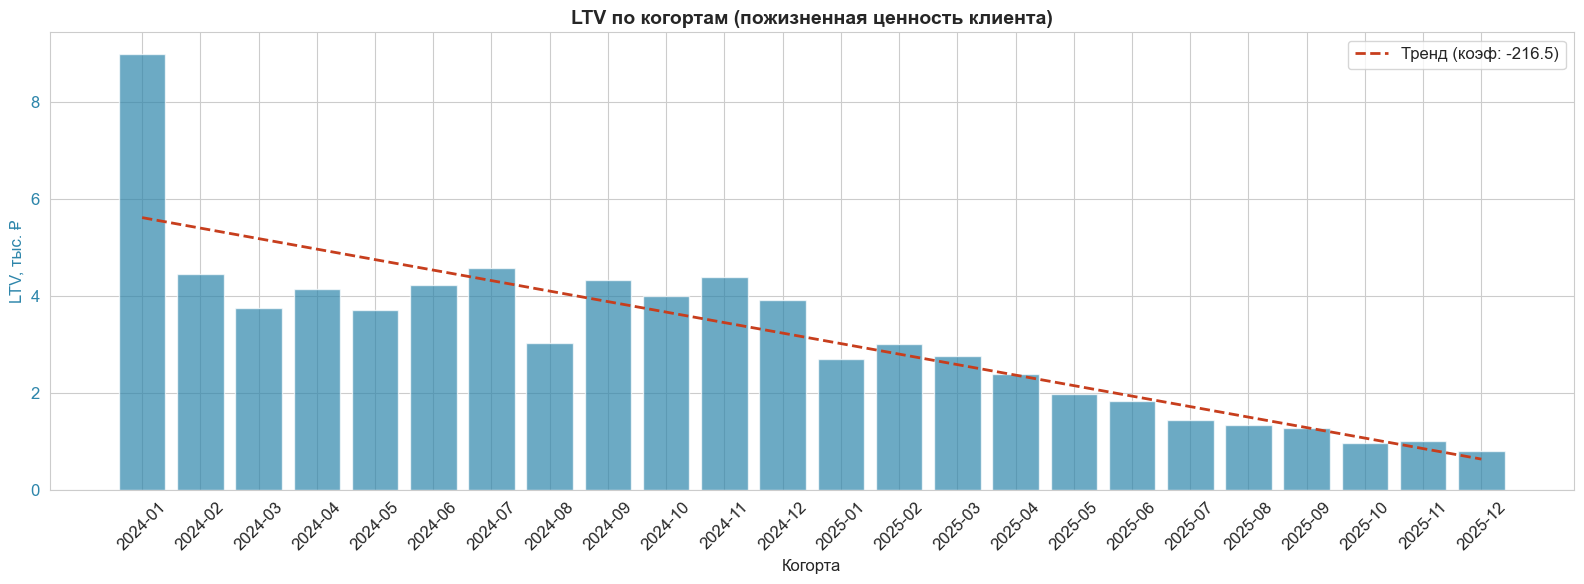


Средний LTV по всем когортам: 3,125 ₽
Максимальный LTV: 8,986 ₽ (когорта 2024-01)
Минимальный LTV: 811 ₽ (когорта 2025-12)


In [13]:
# Привожу типы к строке для корректного merge
sales_for_ltv = sales.copy()
sales_for_ltv["order_month_str"] = sales_for_ltv["order_month"].astype(str)
cohort_data["order_month_str"] = cohort_data["order_month"].astype(str)

# Считаю суммарную выручку каждой когорты за всё время
cohort_revenue = cohort_data.merge(
    sales_for_ltv[["customer_id", "order_month_str", "unit_price"]],
    left_on=["customer_id", "order_month_str"],
    right_on=["customer_id", "order_month_str"]
).groupby("cohort_month")["unit_price"].sum().reset_index()
cohort_revenue.columns = ["cohort_month", "total_revenue"]

# Присоединяю размер когорты
cohort_ltv = cohort_sizes.merge(cohort_revenue, on="cohort_month")
cohort_ltv["ltv"] = (cohort_ltv["total_revenue"] / cohort_ltv["cohort_size"]).round(0)
cohort_ltv = cohort_ltv.sort_values("cohort_month")

print("LTV по когортам:")
print(cohort_ltv[["cohort_month", "cohort_size", "total_revenue", "ltv"]].to_string(index=False))

# График
fig, ax1 = plt.subplots(figsize=(16, 6))

bars = ax1.bar(cohort_ltv["cohort_month"], cohort_ltv["ltv"] / 1000, 
               color=COLORS["primary"], alpha=0.7, edgecolor="white")
ax1.set_xlabel("Когорта")
ax1.set_ylabel("LTV, тыс. ₽", color=COLORS["primary"])
ax1.tick_params(axis="y", labelcolor=COLORS["primary"])
ax1.tick_params(axis="x", rotation=45)

# Добавляю линию тренда
x = range(len(cohort_ltv))
y = cohort_ltv["ltv"].values
if len(x) > 2:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax1.plot(x, p(x) / 1000, color=COLORS["warning"], linestyle="--", linewidth=2, 
             label=f"Тренд (коэф: {z[0]:.1f})")
    ax1.legend()

ax1.set_title("LTV по когортам (пожизненная ценность клиента)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nСредний LTV по всем когортам: {cohort_ltv['ltv'].mean():,.0f} ₽")
print(f"Максимальный LTV: {cohort_ltv['ltv'].max():,.0f} ₽ (когорта {cohort_ltv.loc[cohort_ltv['ltv'].idxmax(), 'cohort_month']})")
print(f"Минимальный LTV: {cohort_ltv['ltv'].min():,.0f} ₽ (когорта {cohort_ltv.loc[cohort_ltv['ltv'].idxmin(), 'cohort_month']})")

### 5.2. LTV по RFM-сегментам

                  customers  total_revenue  avg_ltv  avg_orders  avg_recency  revenue_share
segment                                                                                    
Спящие                  798      8,268,165   10,361          15           35             57
Лояльные                258      2,171,112    8,415          12          272             15
Чемпионы                  4         30,926    7,731          11          418              0
Перспективные           108        281,673    2,608           4          302              2
Средние                 690      1,063,338    1,541           2          143              7
Потерянные              806      1,125,452    1,396           2           40              8
Новые / растущие       1346      1,596,793    1,186           2          405             11


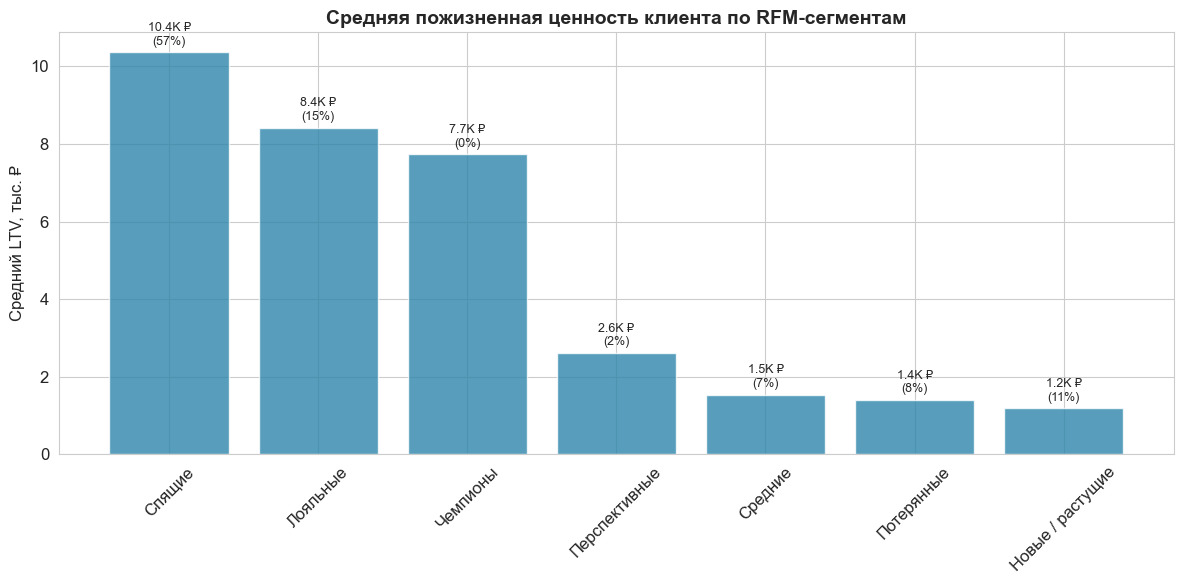

In [14]:
# Средняя выручка клиента в каждом RFM-сегменте
segment_ltv = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    total_revenue=("monetary", "sum"),
    avg_ltv=("monetary", "mean"),
    avg_orders=("frequency", "mean"),
    avg_recency=("recency_days", "mean"),
).round(0)

segment_ltv = segment_ltv.sort_values("avg_ltv", ascending=False)
segment_ltv["revenue_share"] = (segment_ltv["total_revenue"] / rfm["monetary"].sum() * 100).round(1)

print(segment_ltv.to_string())

# График
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(segment_ltv.index, segment_ltv["avg_ltv"] / 1000, 
              color=[COLORS["profit"] if v > 3000 else COLORS["primary"] for v in segment_ltv["avg_ltv"]],
              alpha=0.8, edgecolor="white")

# Подписи
for bar, (ltv, share) in enumerate(zip(segment_ltv["avg_ltv"], segment_ltv["revenue_share"])):
    ax.text(bar, ltv / 1000 + 0.2, f'{ltv/1000:.1f}K ₽\n({share:.0f}%)', 
            ha="center", fontsize=9)

ax.set_ylabel("Средний LTV, тыс. ₽")
ax.set_title("Средняя пожизненная ценность клиента по RFM-сегментам", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 5.3. Выводы по LTV

**LTV по когортам:**
- **Средний LTV — 3 125 ₽** за 2 года. Это базовая планка: если привлечение клиента стоит дороже этой суммы — бизнес работает в минус.
- **Январь 2024 — рекордная когорта:** LTV = 8 986 ₽. Эти клиенты не только пришли первыми, но и лучше удерживались (см. когортный анализ).
- **LTV падает от когорты к когорте.** Коэффициент тренда отрицательный: ранние когорты (2024-01, 2024-07) показывают 4 500–9 000 ₽, поздние (2025-10, 2025-12) — 800–1 000 ₽.
- **Причины падения:**
  - Ухудшение удержания (тренд retention падает).
  - Снижение размера когорт (меньше клиентов = меньше суммарной выручки).
- **Зрелые когорты (прожившие 18+ месяцев) стабилизируются на уровне 3 000–4 500 ₽.** Это реалистичный LTV для бизнеса после 1.5 лет жизни клиента.

**LTV по RFM-сегментам:**
- **«Спящие» — самый ценный сегмент по LTV (10 361 ₽).** Это клиенты, которые много покупали, но давно не возвращались. Их реактивация — главный резерв роста.
- **«Лояльные» — 8 415 ₽.** Стабильно покупающие клиенты. Удержание этого сегмента критически важно.
- **«Чемпионы» — 7 731 ₽, но их всего 4 человека.** Масштабирование этого сегмента невозможно без общего роста удержания.
- **Разрыв между «Спящими» и «Новыми» — в 9 раз (10 361 vs 1 186).** Это отражает путь клиента: от первой покупки (1 186 ₽) до активного потребления (10 361 ₽). Задача бизнеса — провести клиента по этому пути, а не терять после первого заказа.
- **«Новые / растущие» (34% базы) имеют LTV всего 1 186 ₽.** Это ожидаемо для недавно пришедших клиентов, но если они не вырастут до «Средних» или «Лояльных» — их привлечение убыточно.

**Что это означает для бизнеса:**
- **LTV падает — бизнес теряет способность удерживать клиентов.** Это системная проблема, а не сезонное колебание.
- **Реактивация «Спящих» — быстрая победа.** 798 клиентов со средним LTV 10 361 ₽, которые давно не покупали. Даже 10% их возврата даст ~800 тыс. ₽ дополнительной выручки.
- **Новые клиенты не оправдывают привлечение.** Если CAC выше 1 200 ₽ — бизнес теряет деньги на каждом новом клиенте. Нужно либо снижать CAC, либо повышать LTV через удержание.
- **Для полной картины нужны данные о затратах на привлечение (CAC).** Рекомендую бизнесу собрать маркетинговые расходы по каналам для следующего этапа анализа.
---

## 6. Итоговые выводы и рекомендации

Я завершил анализ клиентской базы — от RFM-сегментации до когортного удержания и LTV. Ниже — ключевые находки и конкретные шаги для увеличения клиентской ценности.

### Ключевые находки

**1. Бизнес не удерживает клиентов.**
- 73% клиентов не возвращаются после первой покупки — это главная точка потерь.
- Удержание на 1-й месяц упало с 54% (начало 2024) до 8–18% (конец 2025). Тренд — минус 1 п.п. в месяц.
- Только 4 клиента попадают в сегмент «Чемпионы» — бизнес не создаёт клиентов с высокой частотой и свежестью.

**2. «Спящие» — главный актив и главный резерв.**
- 798 клиентов (20% базы) приносят 57% выручки (8.3 млн ₽).
- Их средний LTV — 10 361 ₽, но они давно не покупали.
- Реактивация даже 10% из них может дать ~800 тыс. ₽ дополнительной выручки.

**3. Новые клиенты не растут.**
- 1 346 клиентов (34% базы) — «Новые / растущие» со средним LTV 1 186 ₽ и 2 заказами.
- Если они не совершат третью-четвёртую покупку, их привлечение не окупится.
- Размер новых когорт снижается: с 385 (январь 2024) до 91–130 (конец 2025).

**4. LTV падает от когорты к когорте.**
- Ранние когорты: 4 500–9 000 ₽. Поздние: 800–1 000 ₽.
- Частично это ограничение данных (поздние когорты прожили меньше месяцев в периоде наблюдения), но тренд ухудшения удержания подтверждает проблему.
- Зрелые когорты стабилизируются на уровне 3 000–4 500 ₽ — это реалистичный LTV для клиента после 1.5 лет жизни.

### Рекомендации

**Приоритет 1: Остановить отток после первой покупки.**
- Внедрить welcome-цепочку: письмо сразу после заказа → напоминание через 3 дня → промокод на второй заказ через 7 дней.
- Настроить триггерные рассылки: «брошенная корзина», «рекомендации на основе первой покупки».
- Цель: поднять удержание на 1-й месяц с текущих 8–27% до 40%. Эффект: +500–700 новых постоянных клиентов в год.

**Приоритет 2: Реактивировать «Спящих».**
- Запустить email-кампанию с персональными промокодами для сегмента «Спящие».
- Предложить ограниченную по времени скидку или бесплатную доставку.
- Цель: вернуть 10–15% спящих (80–120 клиентов). Эффект: +800 тыс. — 1.2 млн ₽.

**Приоритет 3: Выстроить программу лояльности для «Лояльных».**
- 258 клиентов со средним LTV 8 415 ₽ — их нельзя терять.
- Персональные условия, ранний доступ к новинкам, накопительная скидка.
- Цель: удержать 90% лояльных. Эффект: сохранение ~2 млн ₽ выручки ежегодно.

**Приоритет 4: Собрать данные по CAC.**
- Для полной картины нужны маркетинговые расходы по каналам привлечения.
- Без этого невозможно оценить окупаемость привлечения и перераспределить бюджет в пользу эффективных каналов.

### Ожидаемый эффект

| Мера | Ожидаемый эффект |
|---|---|
| Удержание после первой покупки (рост retention с 27% до 40%) | +500–700 постоянных клиентов, +1–2 млн ₽ выручки |
| Реактивация 10% «Спящих» | +800 тыс. ₽ выручки |
| Программа лояльности для «Лояльных» | Сохранение ~2 млн ₽ выручки |
| **Итого** | **+3–5 млн ₽ дополнительной выручки за 2 года** |

### Что дальше?

В ноутбуке 04 я проанализирую товарные запасы и оборачиваемость — вторую ключевую проблему бизнеса, выявленную в ноутбуке 02. Оптимизация закупок и сокращение неликвидов могут дать сопоставимый финансовый эффект.